<a href="https://colab.research.google.com/github/MathewBiddle/ioos_metrics/blob/dac_sizes/ioos_dac_sizes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calculate disk space for each IOOS DAC

## Start with NGDAC

In [ ]:
import pandas as pd

url = 'https://gliders.ioos.us/erddap/files/'

df = pd.read_html(url)

response = df[1].dropna(subset="Name")

response["url"] = "https://gliders.ioos.us/erddap/files/"+response["Name"]

df_gdac = pd.DataFrame()

for url in response.loc[response["Name"].str.contains("/"), "url"]:
  print(f'Collecting sizes from {url}')
  df = pd.read_html(url)[2].dropna(subset="Size")
  df = df.loc[df["Name"]!="Parent Directory"]
  df['Size'] = df['Size'].astype(float)

  df_gdac = pd.concat([df_gdac, df])

print(f'Glider DAC is currently {df_gdac.Size.sum()} bytes (or {df_gdac.Size.sum()**9.3132257461548E-10} GB).')

<ipython-input-27-4bf90ea8914a>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  response["url"] = "https://gliders.ioos.us/erddap/files/"+response["Name"]
<ipython-input-27-4bf90ea8914a>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size'] = df['Size'].astype(float)
<ipython-input-27-4bf90ea8914a>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

HTTPError: HTTP Error 503: 

In [ ]:
print(f'Glider DAC is currently {df_gdac.Size.sum()} bytes (or {df_gdac.Size.sum()**9.3132257461548E-10:.2f} GB).')

Glider DAC is currently 1243992102065.0 bytes (or 1.00 GB).


In [ ]:
df_gdac.shape

(3011976, 5)

In [ ]:
df['Size'] = df['Size'].astype(float)

In [ ]:
df_gdac

,Unnamed: 0,Name,Last modified,Size,Description
2,NaN,amelia_20180501T1458Z_rt.nc,05-Jul-2022 10:44,175215.0,NaN
3,NaN,amelia_20180501T1512Z_rt.nc,05-Jul-2022 10:45,174927.0,NaN
4,NaN,amelia_20180501T1520Z_rt.nc,05-Jul-2022 10:40,174639.0,NaN
5,NaN,amelia_20180501T1542Z_rt.nc,05-Jul-2022 10:40,215669.0,NaN
6,NaN,amelia_20180501T1555Z_rt.nc,05-Jul-2022 10:41,215396.0,NaN
...,...,...,...,...,...
1480,NaN,Sam_20160812T041856Z_rt.nc,29-Feb-2024 00:22,49108.0,NaN
1481,NaN,Sam_20160812T042816Z_rt.nc,29-Feb-2024 00:10,49140.0,NaN
1482,NaN,Sam_20160812T043741Z_rt.nc,29-Feb-2024 00:35,49132.0,NaN
1483,NaN,Sam_20160812T044704Z_rt.nc,29-Feb-2024 00:39,49108.0,NaN


In [ ]:
url

'https://gliders.ioos.us/erddap/files/Sam-20170103T1836/'

## NCEI sizes

['https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-SECOORA',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-SCCOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-PacIOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-NERACOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-NANOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-MARACOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-GLOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-GCOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-CeNCOOS',
 'https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-CARICOOS',
 'https://www.ncei.noaa.gov/access

In [ ]:
!pip install stamina owslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.1/240.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
import urllib.error
import xml.etree.ElementTree as ET
from urllib.request import urlopen

import stamina
from owslib import util

from owslib.iso import namespaces

# Append gmi namespace to namespaces dictionary.
namespaces.update({"gmi": "http://www.isotc211.org/2005/gmi"})
namespaces.update({"gml": "http://www.opengis.net/gml/3.2"})
del namespaces[None]

In [ ]:
@stamina.retry(on=urllib.error.HTTPError, attempts=3)
def openurl(url):
    """Thin wrapper around urlopen adding stamina."""
    return urlopen(url)

## USE NCEI ISO metadata to grab the needed information

Heavily leveraging https://ioos.github.io/ioos_code_lab/content/code_gallery/data_access_notebooks/2017-06-12-NCEI_RA_archive_history.html



In [ ]:
collections = pd.read_html('https://ioos.github.io/ncei-archiving-cookbook/')[0]["Metadata (Link)"].tolist()

df_ncei = pd.DataFrame()

# For each collection
for record in collections:
    url = f'{record};view=xml;responseType=text/xml'
    iso = openurl(url)
    iso_tree = ET.parse(iso)
    root = iso_tree.getroot()

    # Collect package size information.
    # Iterate through transfer size nodes.
    for trans_size in root.iterfind(".//gmd:transferSize", namespaces):
        if trans_size.find(".//gco:Real", namespaces).text:
            sizes = trans_size.find(".//gco:Real", namespaces).text

            df = pd.DataFrame({"pipeline_short_name": [record.split(":")[-1]],
                               "package_size_mb": [sizes],
                               "record": [url],
            })

            df_ncei = pd.concat([df_ncei, df])
            break
        break

    # Collect url access details
    for CI_OnlineResource in root.iterfind(
        ".//gmd:distributorTransferOptions/gmd:MD_DigitalTransferOptions/gmd:onLine/gmd:CI_OnlineResource", namespaces
        ):

      if CI_OnlineResource.find(".//gmd:protocol/gco:CharacterString", namespaces).text == "HTTPS":
        https_url = CI_OnlineResource.find('.//gmd:linkage/gmd:URL',namespaces).text
        df_ncei.loc[df_ncei["record"]==url,'https_url'] = [https_url]

    for CI_ResponsibleParty in root.iterfind(
        ".//gmd:citedResponsibleParty/gmd:CI_ResponsibleParty", namespaces
        ):
      #print(ET.tostring(CI_ResponsibleParty))
      if CI_ResponsibleParty.find(".//gmd:role/gmd:CI_RoleCode",namespaces).text == "resourceProvider":
        if (record.split(":")[-1] == "IOOS-ATN-STP") or (record.split(":")[-1] == "IOOS-NGDAC"):
          poc_name = CI_ResponsibleParty.find(".//gmd:name/gco:CharacterString",namespaces).text
          poc_email = CI_ResponsibleParty.find(".//gmd:URL", namespaces).text
        else:
          poc_name = CI_ResponsibleParty.find(".//gmd:individualName/gmx:Anchor",namespaces).text
          poc_email = CI_ResponsibleParty.find(".//gmd:electronicMailAddress/gco:CharacterString", namespaces).text

        df_ncei.loc[df_ncei["record"]==url,"poc_name"] = poc_name
        df_ncei.loc[df_ncei["record"]==url,"poc_email"] = poc_email
        break # get first one

    for dateStamp in root.iterfind(".//gmd:dateStamp", namespaces):
      update_date = dateStamp.find(".//gco:DateTime", namespaces).text
      df_ncei.loc[df_ncei["record"]==url,"update_date"] = update_date

df_ncei

IOOS-SECOORA Size = 410.116 MB
IOOS-SCCOOS Size = 269.22 MB
IOOS-PacIOOS Size = 3979.576 MB
IOOS-NERACOOS Size = 11360.52 MB
IOOS-NANOOS Size = 39939.428 MB
IOOS-MARACOOS Size = 3739.072 MB
IOOS-GLOS Size = 414.552 MB
IOOS-GCOOS Size = 19254.64 MB
IOOS-CeNCOOS Size = 774.712 MB
IOOS-CARICOOS Size = 93.228 MB
IOOS-AOOS Size = 805.22 MB
IOOS-ATN-STP Size = 32.892 MB
IOOS-HFRadarRadial Size = 7943841.916 MB
IOOS-HFRadarRTVector Size = 242939.384 MB
IOOS-NGDAC Size = 139833.844 MB


,pipeline_short_name,package_size_mb,record,https_url,poc_name,poc_email,update_date
0,IOOS-SECOORA,410.116,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/sec...,Jeremy Cothran,jeremy.cothran@gmail.com,2025-03-31T21:15:27Z
0,IOOS-SCCOOS,269.22,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/scc...,Darren Wright,darren@cdip.ucsd.edu,2025-04-21T13:42:01Z
0,IOOS-PacIOOS,3979.576,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/pac...,James T. Potemra,jimp@hawaii.edu,2025-04-18T14:11:34Z
0,IOOS-NERACOOS,11360.52,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/ner...,Tom Shyka,tom@neracoos.org,2025-03-31T17:24:58Z
0,IOOS-NANOOS,39939.428,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/nan...,Emilio Mayorga,mayorga@apl.washington.edu,2025-03-31T21:04:38Z
0,IOOS-MARACOOS,3739.072,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/mar...,Kelly Knee,Kelly.knee@rpsgroup.com,2025-03-31T21:09:25Z
0,IOOS-GLOS,414.552,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/glos/,Guan Wang,gwang@glc.org,2025-03-31T21:07:38Z
0,IOOS-GCOOS,19254.64,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/gcoos/,Matthew K. Howard,mkhoward@tamu.edu,2025-04-04T17:41:39Z
0,IOOS-CeNCOOS,774.712,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/cen...,Kyle Wilcox,kyle@axiomdatascience.com,2025-03-31T17:34:07Z
0,IOOS-CARICOOS,93.228,https://www.ncei.noaa.gov/access/metadata/land...,https://www.ncei.noaa.gov/data/oceans/ioos/car...,Jorge E. Capella,jorge.capella@upr.edu,2025-03-31T21:08:18Z


In [ ]:
print(df_ncei.to_markdown(index=False))

| pipeline_short_name   |   package_size_mb | record                                                                                                                              | https_url                                                  | poc_name                                                                        | poc_email                          | update_date          |
|:----------------------|------------------:|:------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------|:--------------------------------------------------------------------------------|:-----------------------------------|:---------------------|
| IOOS-SECOORA          |     410.116       | https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:IOOS-SECOORA;view=xml;responseType=text/xml         | https://www.ncei.noaa.gov/data/oceans/ioos/secoora/   

## OBIS sizes

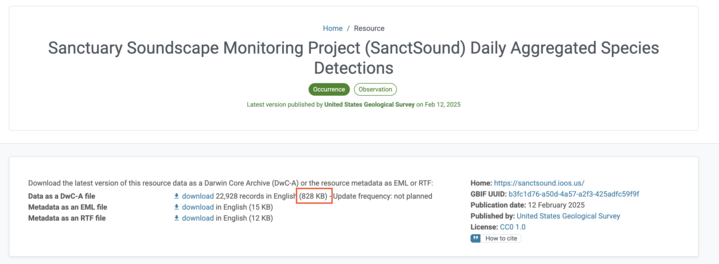

In [1]:
!pip install ioos_metrics

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 28.5 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=7142add3ed7227ab2c60cea036c1002d581d74029823b57c5393219ab50b92b1
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built docopt


In [11]:
from ioos_metrics import ioos_metrics

In [12]:
df = ioos_metrics.mbon_stats()

In [13]:
df

,literature_title,literature_authors,literature_source,literature_discovered,literature_published,literature_open_access,literature_peer_review,literature_citation_type,literature_countries_of_coverage,literature_countries_of_researcher,...,obis_feed,obis_institutes,obis_contacts,obis_nodes,obis_keywords,obis_downloads,obis_records,title,doi,gbif_downloads
0,50 years of invertebrate conservation under th...,Vaughn M. Shirey|Jayme M.M. Lewthwaite|Ann Mar...,Frontiers in Conservation Science,2025-04-20,2025-04-01T00:00:00.000Z,True,True,DOI,UNITED_STATES,CANADA|UNITED_STATES,...,"{'id': '8112d75b-7e78-4641-9e09-9a2cc7db7375',...",[{'name': 'National Oceanic and Atmospheric Ad...,"[{'role': None, 'type': 'creator', 'givenname'...",[{'id': 'b7c47783-a020-4173-b390-7b57c4fa1426'...,"[{'keyword': 'Samplingevent', 'thesaurus': 'GB...","[{'year': 2025, 'downloads': 1149, 'records': ...",156,Vessel line-transect surveys of Arctic cetacea...,10.15468/fxjpbr,"{'number_downloads': {2020: 875, 2021: 949, 20..."
1,Global impact of the COVID-19 lockdown on biod...,Stephanie Roilo|Jan O. Engler|Anna F. Cord,Scientific Reports,2025-03-07,2025-03-13T00:00:00.000Z,True,True,DOI,NaN,GERMANY,...,"{'id': '8112d75b-7e78-4641-9e09-9a2cc7db7375',...",[{'name': 'National Oceanic and Atmospheric Ad...,"[{'role': None, 'type': 'creator', 'givenname'...",[{'id': 'b7c47783-a020-4173-b390-7b57c4fa1426'...,"[{'keyword': 'Samplingevent', 'thesaurus': 'GB...","[{'year': 2025, 'downloads': 1149, 'records': ...",156,Vessel line-transect surveys of Arctic cetacea...,10.15468/fxjpbr,"{'number_downloads': {2020: 875, 2021: 949, 20..."
2,Unprecedented heat threatened 1 in 10 vertebra...,Cory Merow|Josep Serra-Diaz|Ben Carlson|Brian ...,Research Square,2025-01-28,2025-01-24T00:00:00.000Z,True,False,DOI,NaN,SPAIN|SOUTH_AFRICA|UNITED_KINGDOM|UNITED_STATES,...,"{'id': '8112d75b-7e78-4641-9e09-9a2cc7db7375',...",[{'name': 'National Oceanic and Atmospheric Ad...,"[{'role': None, 'type': 'creator', 'givenname'...",[{'id': 'b7c47783-a020-4173-b390-7b57c4fa1426'...,"[{'keyword': 'Samplingevent', 'thesaurus': 'GB...","[{'year': 2025, 'downloads': 1149, 'records': ...",156,Vessel line-transect surveys of Arctic cetacea...,10.15468/fxjpbr,"{'number_downloads': {2020: 875, 2021: 949, 20..."
3,A generative deep learning approach for global...,Y. YAN|B. SHAO|C. C. Davis,bioRxiv,2024-12-20,2024-12-16T00:00:00.000Z,True,False,DOI,NaN,UNITED_STATES,...,"{'id': '8112d75b-7e78-4641-9e09-9a2cc7db7375',...",[{'name': 'National Oceanic and Atmospheric Ad...,"[{'role': None, 'type': 'creator', 'givenname'...",[{'id': 'b7c47783-a020-4173-b390-7b57c4fa1426'...,"[{'keyword': 'Samplingevent', 'thesaurus': 'GB...","[{'year': 2025, 'downloads': 1149, 'records': ...",156,Vessel line-transect surveys of Arctic cetacea...,10.15468/fxjpbr,"{'number_downloads': {2020: 875, 2021: 949, 20..."
4,Tides of Transparency: A First Mapping of Ind...,null HUB Ocean,NaN,2024-12-10,2024-12-01T00:00:00.000Z,False,False,DOI,NaN,NaN,...,"{'id': '8112d75b-7e78-4641-9e09-9a2cc7db7375',...",[{'name': 'National Oceanic and Atmospheric Ad...,"[{'role': None, 'type': 'creator', 'givenname'...",[{'id': 'b7c47783-a020-4173-b390-7b57c4fa1426'...,"[{'keyword': 'Samplingevent', 'thesaurus': 'GB...","[{'year': 2025, 'downloads': 1149, 'records': ...",156,Vessel line-transect surveys of Arctic cetacea...,10.15468/fxjpbr,"{'number_downloads': {2020: 875, 2021: 949, 20..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,Seeigel: Verwandtschaft auf abgelegenen Inseln,Niko Komin,NaN,2021-12-08,2021-12-01T00:00:00.000Z,False,False,DOI,NaN,GERMANY,...,"{'id': '8112d75b-7e78-4641-9e09-9a2cc7db7375',...","[{'name': 'U.S. Geological Survey HQ', 'oceane...","[{'role': None, 'type': 'creator', 'givenname'...",[{'id': 'b7c47783-a020-4173-b390-7b57c4fa1426'...,"[{'keyword': 'Samplingevent', 'thesaurus': 'GB...","[{'year': 2025, 'downloads': 2018, 'records': ...",237709,"Abundance of Rocky Reef Fi